In [169]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import pandas as pd
import numpy as np

# https://pypi.org/project/era5cli/

CPU times: user 21 µs, sys: 257 µs, total: 278 µs
Wall time: 1.49 ms


In [170]:
# Project imports
from sutton import (
    Params,
    thomas,
    our_central_difference,
    integrate_T_implicit,
    integrate_H2O_implicit,
    stability,
    saturation_vapor_pressure,
    vapor_concentration_RH,
)

In [171]:
def get_lm(k, h, z, option = 'kz'):
    """
    mixing length options
    """
    d = 2/3*h
    
    if option == 'kz':
        lm = k*z
    else:
        a = 1
        lm = k*z   
        lm[z < a*(h - d)] = k*a*h/3 
  
    return lm


### Boundary conditions from Rao et al (1974)

In [172]:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4

cp_air  = 1005.0     # J kg^-1 K^-1
rho_air = 1.20       # kg m^-3

Lv      = 2.43e6     # J kg^-1
Lv_g    = 2430.0  # J g^-1  (~30 °C)


mcal_to_J = 4.184e-3  # 1 mcal = 4.184e-3 J
cm2_to_m2 = 1e-4      # 1 cm² = 1e-4 m²
H01_mcal_cm2_s = 8.5  # Given value in mcal/cm²/s

# Convert to SI units (W/m²)
H_f = H01_mcal_cm2_s * mcal_to_J / cm2_to_m2
LE_f = 0

Q_f = 6.34 # g mm3, E_01

RH_c = 60 # relative humidity
ustar_f = 0.14



In [265]:

from dataclasses import dataclass, asdict
from typing import Optional
import numpy as np
from functools import cached_property
from sutton import saturation_vapor_pressure, vapor_concentration_RH
import sympy as sp



@dataclass
class Params:
    # --- core physics/numerics  ---
    k: float = 0.4
    zom_f: float = 0.05           # m (wet/downwind momentum roughness)
    zom_c: float = 0.05           # m (dry/upwind momentum roughness)

    # canopy & displacement inputs (per patch)
    # (If None → derive from z0m via alpha_m, disp_frac; see properties below)
    h_f_opt: Optional[float] = None
    h_c_opt: Optional[float] = None
    d_f_opt: Optional[float] = None
    d_c_opt: Optional[float] = None
    alpha_m: float = 0.10          # z0m ≈ alpha_m * h
    disp_frac: float = 0.67        # d ≈ disp_frac * h
    
    G : float = 0
    # domain/grid
    Lx: float = 200.0               # m
    Hmax: float = 20.0              # m
    dz: float = 0.1                  # m
    dx: float = 1                   # m
    xmin: float = 0.0               # m

    # friction velocities (optional; None ⇒ compute later or via resolve_ustars)
    ustar_f: Optional[float] = 0.25
    ustar_c: Optional[float] = 0.25

    # block pattern
    fallow_fraction: float = 0.5
    fallow_length: float = 1000.0  # m

    # temperatures in °C; RH in %
    T_sc: float = 28.5
    T_sf: float = 50.0
    T_a:  float = 30.0
    RH_c: float = 60
        
    Q_a: float = 6.3
    Q_f: float = 6.3

    # radiation inputs 
    SW_in: float = 400.0
    epsilon_f: float = 0.90
    epsilon_c: float = 0.95
    epsilon_a: float = 0.80
    alpha_c: float = 0.22
    alpha_f: float = 0.22

    lm_option: str | None = "kz"

    # reference wind for u* inference (if you compute from log law)
    U_ref: float = 3.76            # m s^-1 at z_ref_wind
    z_ref_wind: float = 4.0        # m

    # Upstream/base flux: Rao base case uses (RN-G)_up = H_f
    H_f: float = 8.5*4.184e-3/1e-4   # ≈ 356 W m^-2
    LE_f: float = 0.0                # upstream LE 
    
    # avail_ratio 1: downstream available energy & partition 
    avail_ratio: float = 1   # (RN-G)_down / (RN-G)_up, dimensionless
    le_factor: float = 1.0             # 0..1: downstream LE_c = le_factor * avail_ratio

    # ----------------- helpers & grids -----------------
    @staticmethod
    def _K(Tc: float) -> float:
        return Tc + 273.15

    # derived canopy height & displacement (per patch)
    @cached_property
    def h_f(self) -> float:
        if self.h_f_opt is not None: return float(self.h_f_opt)
        if self.d_f_opt is not None: return float(self.d_f_opt) / self.disp_frac
        return float(self.zom_f) / self.alpha_m

    @cached_property
    def h_c(self) -> float:
        if self.h_c_opt is not None: return float(self.h_c_opt)
        if self.d_c_opt is not None: return float(self.d_c_opt) / self.disp_frac
        return float(self.zom_c) / self.alpha_m

    @cached_property
    def d_f(self) -> float:
        if self.d_f_opt is not None: return float(self.d_f_opt)
        if self.h_f_opt is not None: return self.disp_frac * float(self.h_f_opt)
        return self.disp_frac * (float(self.zom_f) / self.alpha_m)

    @cached_property
    def d_c(self) -> float:
        if self.d_c_opt is not None: return float(self.d_c_opt)
        if self.h_c_opt is not None: return self.disp_frac * float(self.h_c_opt)
        return self.disp_frac * (float(self.zom_c) / self.alpha_m)

    #  zmin respects (z - d) > z0 → keep grid valid for both patches
    @cached_property
    def zmin(self) -> float:
        thresh_f = self.d_f + self.zom_f
        thresh_c = self.d_c + self.zom_c
        return max(thresh_f, thresh_c)   # conservative global lower bound
        
    @cached_property
    def z(self) -> np.ndarray:
        return np.arange(self.zmin, self.Hmax,  self.dz)

    @cached_property
    def x(self) -> np.ndarray:
        return np.arange(self.xmin, self.Lx + self.dx, self.dx)

    @property
    def nz(self) -> int: return len(self.z)

    @property
    def nx(self) -> int: return len(self.x)

    # u* optional compute (unchanged)
    def resolve_ustars(self):
        if self.ustar_f is None:
            assert self.z_ref_wind > self.zom_f > 0
            self.ustar_f = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_f)
        if self.ustar_c is None:
            assert self.z_ref_wind > self.zom_c > 0
            self.ustar_c = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_c)
        return self

    # block sizes (fixed ternary line break)
    @cached_property
    def fallow_size(self) -> int:
        return int(self.fallow_length / self.dx)

    @cached_property
    def field_size(self) -> int:
        return (
            int(self.fallow_size * (1 - self.fallow_fraction) / self.fallow_fraction)
            if self.fallow_fraction > 0 else 0
        )
    
    @cached_property
    def lm(self):

        d = 2/3*self.h_c
        z = self.z
        k = self.k
        h = self.h_c
        
        if self.lm_option == 'kz':
            lm = k*z
        else:
            a = 1
            lm = k*z   
            lm[z < a*(h - d)] = k*a*h/3 

        return lm

    # Saturation vapor pressure over liquid water (Pa) via Clausius–Clapeyron
    @cached_property
    def es_c(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sc))

    @cached_property
    def es_f(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sf))

    # humidity as absolute humidity (your Q_* names retained)    
    @cached_property
    def Q_c(self) -> float:
        return vapor_concentration_RH(self.T_sc, self.RH_c)
    
    # energy partition
    
    #  upstream available energy  
    @property
    def RNmG_up(self) -> float:
        return self.H_f

    @property
    def RNmG_down(self) -> float:
        """Downstream available energy = avail_ratio * RNmG_up (W m^-2)."""
        return self.RNmG_up * self.avail_ratio    

    # downstream partition 
    @property
    def LE_c(self) -> float:
        lf = min(max(self.le_factor, 0.0), 1.0)
        lf = self.le_factor
        return lf * self.RNmG_up * self.avail_ratio

    @property
    def H_c(self) -> float:
        #lf = min(max(self.le_factor, 0.0), 1.0)
        lf = self.le_factor
        return (1.0 - lf) * self.RNmG_up * self.avail_ratio

    # optional dict for legacy call sites
    def to_dict(self) -> dict:
        d = asdict(self)
        d.update({
            "x": self.x, "z": self.z, 
            "nx": self.nx,  "nz": self.nz,
            "zmin": self.zmin, 
            "zmax": self.Hmax, 
            "xmax": self.Lx,
            "ustar_f": self.ustar_f, 
            "ustar_c": self.ustar_c,
            "fallow_size": self.fallow_size, 
            "field_size": self.field_size,
            "Q_c": self.Q_c, "Q_f": self.Q_f, 
            "Q_a": self.Q_a,
            "es_c": self.es_c, 
            "es_f": self.es_f,
            # partition values
            "LE_c": self.LE_c, 
            "H_c": self.H_c,
            "RNmG_up": self.RNmG_up, 
            "RNmG_down": self.RNmG_down,
            # canopy/displacement (derived)
            "h_f": self.h_f, "h_c": self.h_c, 
            "d_f": self.d_f, "d_c": self.d_c,
        })
        return d


    def solve_surface_radiation_inplace(self, *, fix: str = "alpha_f") -> dict:
        """
        Solve the two-surface net-radiation balances using ONLY internal Params state,
        then update Params in place (SW_in and the free albedo).

          Rn_f = SW*(1 - alpha_f) + eps_a*sigma*T_a^4 - eps_f*sigma*T_sf^4
          Rn_c = SW*(1 - alpha_c) + eps_a*sigma*T_a^4 - eps_c*sigma*T_sc^4

        Rn_f = RNmG_up + G;  Rn_c = RNmG_down + G

        Args
        ----
        fix : {"alpha_f","alpha_c"}
            Which albedo to treat as fixed (kept from Params). The other is solved.

        Returns
        -------
        dict with {"SW": float, "alpha_f": float, "alpha_c": float, "Rn_f": float, "Rn_c": float}
        """
        if fix not in ("alpha_f", "alpha_c"):
            raise ValueError("fix must be 'alpha_f' or 'alpha_c'.")

        # Upstream/downstream net radiation from internal partition + ground flux
        Rn_f = float(self.RNmG_up + self.G)
        Rn_c = float(self.RNmG_down + self.G)

        # Temps (°C -> K)
        TaK  = self._K(self.T_a)
        TsfK = self._K(self.T_sf)
        TscK = self._K(self.T_sc)

        # Symbols and constants
        SW = sp.symbols('SW', real=True)
        sigma = sigma_sb
        ea, ef, ec = self.epsilon_a, self.epsilon_f, self.epsilon_c

        if fix == "alpha_f":
            # Unknowns: SW, alpha_c  (alpha_f fixed from Params)
            alpha_c_sym = sp.symbols('alpha_c', real=True)
            eq1 = sp.Eq(SW*(1 - self.alpha_f) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - alpha_c_sym) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_c_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_c). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_c_val = float(sol[0][alpha_c_sym])

            # Clip to physical range [0,1] with a gentle nudge/warn if needed
            alpha_c_val = min(max(alpha_c_val, 0.0), 1.0)

            # update params in place
            self.SW_in  = SW_val
            self.alpha_c = alpha_c_val

            return {"SW": SW_val, "alpha_f": float(self.alpha_f), "alpha_c": alpha_c_val,
                    "Rn_f": Rn_f, "Rn_c": Rn_c}

        else:
            # fix == "alpha_c": Unknowns: SW, alpha_f  (alpha_c fixed from Params)
            alpha_f_sym = sp.symbols('alpha_f', real=True)
            eq1 = sp.Eq(SW*(1 - alpha_f_sym) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - self.alpha_c) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_f_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_f). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_f_val = float(sol[0][alpha_f_sym])

            alpha_f_val = min(max(alpha_f_val, 0.0), 1.0)

            # update params in place
            self.SW_in   = SW_val
            self.alpha_f = alpha_f_val

            return {"SW": SW_val, 
                    "alpha_f": alpha_f_val, 
                    "alpha_c": float(self.alpha_c),
                    "Rn_f": Rn_f, "Rn_c": Rn_c}


    def update_surface_BCs_from_reference(self) -> dict:
        """
        Update both wall BCs (T_sc, T_sf, Q_c, Q_f) assuming the reference air
        state (T_a, Q_a) is at z_ref = p.z[0]. Neutral two-point form:
          T_s = T_a + (H/(rho*cp*u_* * k)) * ln(z_h / z_ref)
          Q_s = Q_a + (1000*LE/(lv*u_* * k)) * ln(z_h / z_ref)   [Q in g m^-3]
        """
        z_h   = float(self.Hmax)
        z_ref = float(self.z[0])
        kappa = float(self.k)

        log_frac = np.log(z_h / z_ref)

        # cultivated (c)
        T_sc_new = self.T_a + (self.H_c  / (rho_air * cp_air * self.ustar_c * kappa)) * log_frac
        Q_c_new  = self.Q_a + (self.LE_c / (Lv_g * self.ustar_c * kappa)) * log_frac        
        self.T_sc = float(T_sc_new)
        for name in ("es_c","Q_c"): self.__dict__.pop(name, None)
        self.__dict__["Q_c"] = float(Q_c_new)

        # fallow (f)
        T_sf_new = self.T_a + (self.H_f  / (rho_air * cp_air * self.ustar_f * kappa)) * log_frac
        Q_f_new  = self.Q_a + (self.LE_f / (Lv_g * self.ustar_f * kappa)) * log_frac
        self.T_sf = float(T_sf_new)
        for name in ("es_f","Q_f"): self.__dict__.pop(name, None)
        self.__dict__["Q_f"] = float(Q_f_new)

        return {"z_ref": z_ref, "T_sc": self.T_sc, "T_sf": self.T_sf,
                "Q_c": float(Q_c_new), "Q_f": float(Q_f_new)}


    def update_surface_BCs_from_zom(self) -> dict:
        """
        Update both wall BCs (T_sc, T_sf, Q_c, Q_f) assuming the reference air
        state (T_a, Q_a) is at z = zmax (self.Hmax). Uses neutral log relations:

          T_s = T_a + (H / (rho cp u* k)) * ln(zmax / z0h)
          Q_s = Q_a + (1000 * LE / (lv u* k)) * ln(zmax / z0q)   [Q in g m^-3]
        """
        zmax  = float(self.Hmax)
        kappa = float(self.k)

        if self.ustar_c is None or self.ustar_f is None:
            raise ValueError("ustar_f/ustar_c is None. set them or call resolve_ustars().")

        z0h_c = self.zom_c
        z0q_c = self.zom_c        
        z0h_f = self.zom_f
        z0q_f = self.zom_f

        # ---- cultivated (c) ----
        T_sc_new = self.T_a + (self.H_c / (rho_air * cp_air * self.ustar_c * kappa)) * np.log(zmax / z0h_c)
        Q_c_new  = self.Q_a + ( self.LE_c / (Lv_g * self.ustar_c * kappa)) * np.log(zmax / z0q_c)
    
        self.T_sc = float(T_sc_new)
        for name in ("es_c", "Q_c"):
            self.__dict__.pop(name, None)
        self.__dict__["Q_c"] = float(Q_c_new)

        # ---- fallow (f) ----
        T_sf_new = self.T_a + (self.H_f/(rho_air * cp_air * self.ustar_f * kappa)) * np.log(zmax / z0h_f)
        Q_f_new  = self.Q_a + (self.LE_f/(Lv_g * self.ustar_f * kappa)) * np.log(zmax / z0q_f)

        self.T_sf = float(T_sf_new)
        for name in ("es_f", "Q_f"):
            self.__dict__.pop(name, None)
        self.__dict__["Q_f"] = float(Q_f_new)

        return {"z_ref": zmax, "T_sc": self.T_sc, "T_sf": self.T_sf, "Q_c": float(Q_c_new), 
                "Q_f": float(Q_f_new)}


def no_central_difference(s, z):
    """
    Central differences; forward/backward at edges.
    """
    m = len(z)
    dz = np.ones(m)
    ds = np.ones(m)
    dz[:-1] = np.log(z[1:] / z[: -1])
    
    ds[:-1] = (s[1:] - s[: -1])    
    ds_dz = ds/dz
    ds_dz[-1] = ds_dz[-2]
    
    return ds_dz

def integrate_H2O_implicit(p, Q_up, A, B, C):
    """
    One x-step implicit solve for absolute humidity Q (g m^-3).
    BCs: surface Q = p.Q_c, aloft Q = p.Q_a.
    A, B, C : arrays length nz
    """
    
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z = p.z
    
    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = Q_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.Q_c
    co[m - 1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)


    Fq = - A/z *  dQdz
    return Q1, Fq

    
def integrate_T_implicit(p, T_up, A, B, C):
    """
    One x-step implicit solve for temperature T (°C).
    BCs: surface T = p.T_sc, aloft T = p.T_a.
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z
    
    AA1 = - A * B
    AA2 = - C * B
    AA3 = 1 / dx
    AA4 = T_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.T_sc
    co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)
   
    FT = np.zeros_like(T1)
    FT = - (A/z) * dTdz


    return T1, FT


def uniform_Q(p: Params):
    """
    Implicit solution for water-vapor concentration (absolute humidity, g m^-3)
    and its mass flux (g m^-2 s^-1) in a turbulent boundary layer.

    Uses:
      - neutral log wall-profiles to set upwind/downwind boundary shapes
      - mixing-length eddy diffusivity via get_lm(k, h, z, lm_option)
      - implicit marching in x using integrate_H2O_implicit(...)
    """
    # --- pull scalars/grids from Params ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c

    Q_f, Q_c, Q_a = p.Q_f, p.Q_c, p.Q_a
    z  = p.z
    # downstream 'h' for mixing length (choose p.h_c; change if you prefer p.h_f or another)
    h = p.h_c
    lm_option     = p.lm_option

    # --- upwind & downwind wall-profile shapes (absolute humidity, g m^-3) ---
    FQ_f  = ustar_f * k * (Q_f - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qup   = Q_f - (FQ_f / (k * ustar_f)) * np.log(z / z[0])   # g m^-3

    FQ_c  = ustar_c * k * (Q_c - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qdown = Q_c - (FQ_c / (k * ustar_c)) * np.log(z / z[0])   # g m^-3

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (z[0] + 1e-9))

    # --- coefficients for implicit scheme ---
    lm = get_lm(k, h, z, lm_option)      # mixing length [m]
    A  = lm * ustar_c                    # turbulent diffusivity scale
    B  = 1.0 / U                         # 1/U for advection term
    C  = our_central_difference(A, dz)   # your operator builder

    # --- initialize march in x ---
    Q1 = Qup.copy()
    Q_uniform     = np.zeros((nx, nz))
    FluxQ_uniform = np.zeros((nx, nz))
    Q_uniform[0, :] = Q1

    for i in range(nx):

        Q2, Fq = integrate_H2O_implicit(p, Q1, A, B, C)
        Q_uniform[i, :]     = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform   # g m^-3, g m^-2 s^-1

def uniform_T(p: Params):
    """
    Implicit solution for temperature (°C) and its vertical kinematic heat flux (K m s^-1)
    in a turbulent boundary layer, marched along x.

    Notes:
      - Uses neutral log wall-profiles to set up/downstream temperature shapes.
      - Uses mixing-length eddy diffusivity via get_lm(k, h, z, lm_option).
      - Units follow your original code (wT in K m s^-1).
    """
    # --- pull scalars/grids ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c
    if ustar_f is None or ustar_c is None:
        raise ValueError("ustar_f/ustar_c is None; set them or call p.resolve_ustars().")

    T_sf, T_sc, T_a = p.T_sf, p.T_sc, p.T_a
    z               = p.z
    h               = p.h_c
    lm_option       = p.lm_option

    # --- upwind & downwind wall-profile shapes (°C) ---
    wT_up   = - (T_a - T_sf) * k * ustar_f / np.log(zmax / z[0])   # K m s^-1
    Tup     = T_sf - (wT_up / (k * ustar_f)) * np.log(z / z[0])

    wT_down = - (T_a - T_sc) * k * ustar_c / np.log(zmax / z[0])   # K m s^-1
    Tdown   = T_sc - (wT_down / (k * ustar_c)) * np.log(z / z[0])

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (z[0] + 1e-9) )

    # --- coefficients for implicit scheme ---
    lm = get_lm(k, h, z, lm_option)

    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    # --- initialize march in x ---
    T1 = Tup.copy()
    T_uniform     = np.zeros((nx, nz))
    FluxT_uniform = np.zeros((nx, nz))
    T_uniform[0, :] = T1

    for i in range(nx):

        T2, FT = integrate_T_implicit(p, T1, A, B, C)
        T_uniform[i, :]     = T2
        FluxT_uniform[i, :] = FT
        T1 = T2

    return T_uniform, FluxT_uniform

def get_upwind_fluxQ(p: Params):
    """
    Build the upwind absolute-humidity profile Q_up (g m^-3) and its
    diffusive mass flux profile (g m^-2 s^-1) using neutral two-point logs
    referenced to z0 via ln(zmax / z0).
    """
    # scalars / grids
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    Q_f, Q_a = p.Q_f, p.Q_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    FQ_f   = ustar * k * (Q_f - Q_a) / np.log(zmax / z[0])      # g m^-2 s^-1
    Q_up   = Q_f - (FQ_f / (k * ustar)) * np.log(z / z[0])      # g m^-3
    dQdz   = our_central_difference(Q_up, dz)                    # g m^-4

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1

    dQdz = no_central_difference(Q_up, z)
    FluxQ_upwind = - A/z *  dQdz
    

    return Q_up, FluxQ_upwind


def get_upwind_fluxT(p: Params):
    """
    Build the upwind temperature profile T_up (°C) and its kinematic heat-flux
    profile (K m s^-1) using neutral two-point logs referenced to z0 via ln(zmax / z0).
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    T_sf, T_a = p.T_sf, p.T_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    wT_up = - (T_a - T_sf) * k * ustar / np.log(zmax / z[0])    # K m s^-1
    T_up  = T_sf - (wT_up / (k * ustar)) * np.log(z / z[0])     # °C
    dTdz  = our_central_difference(T_up, dz)                     # K m^-1

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1
    
    dTdz = no_central_difference(T_up, z)
    FluxT_upwind = - A/z *  dTdz
    
    return T_up, FluxT_upwind

level = 0
ustar_f = 0.15
shear_ratio = 2
ustar_c = ustar_f*np.sqrt(shear_ratio)

p = Params(ustar_f = ustar_f, ustar_c = ustar_c,  lm_option = 'kz', avail_ratio = 1., Hmax = 20,
           le_factor = 1, dz = 0.1, dx = 0.5)

out = p.solve_surface_radiation_inplace(fix="alpha_c")
out = p.update_surface_BCs_from_zom()

T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)

T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2


In [270]:
D_T = 50
measure = 2.5
ind_x = np.where(p.x > D_T)[0][0]
ind_z = np.where(p.z > measure)[0][0]

In [271]:
 Q_uniform[ind_x, 0] - Q_up[ 0] 

10.334062256939696

In [272]:
# FROM HIGGINS
(LE_uniform_Wm2[ind_x, 0] - LE_uniform_Wm2[ind_x, ind_z] )

44.92846731918644

In [273]:
U = (p.ustar_c/ p.k) * np.log(p.z / (p.z[0] + 1e-9))
# g/m3 J/g  m/s =  J/m2 s 
Lv_g*U[ind_z]*(Q_uniform[ind_x][ind_z] - Q_up[ind_z])/D_T*measure


472.87577904174833

In [208]:

measures = np.arange(p.z[1], 20, 1)
le_factors = np.arange(0, 1, 0.05)

advection = np.ones([len(measures), len(le_factors)])
delta_Qs = np.ones_like(le_factors)
D_T = 50

for j,le_factor in enumerate(le_factors):
    
    p = Params(ustar_f = ustar_f, ustar_c = ustar_c, lm_option = 'kz', 
               avail_ratio = 1, Hmax = 20,
               le_factor = le_factor, dz = 0.1, dx = 0.5)

    out = p.solve_surface_radiation_inplace(fix="alpha_c")
    out = p.update_surface_BCs_from_zom()

    T_uniform, FluxT_uniform = uniform_T(p)
    Q_uniform, FluxQ_uniform = uniform_Q(p)

    T_up, FluxT_upwind = get_upwind_fluxT(p)
    Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

    H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
    LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
    FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

    H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
    LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
    FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2
    delta_Qs[j] = Q_uniform[10, 0] - Q_up[0] 

    for i, measure in enumerate(measures):

        ind_x = np.where(p.x > D_T)[0][0]
        ind_z = np.where(p.z > measure)[0][0]
        advection[i, j] = LE_uniform_Wm2[ind_x, 0] - LE_uniform_Wm2[ind_x, ind_z] 
        

        

Text(0, 0.5, '$\\Delta Q$ g/kg')

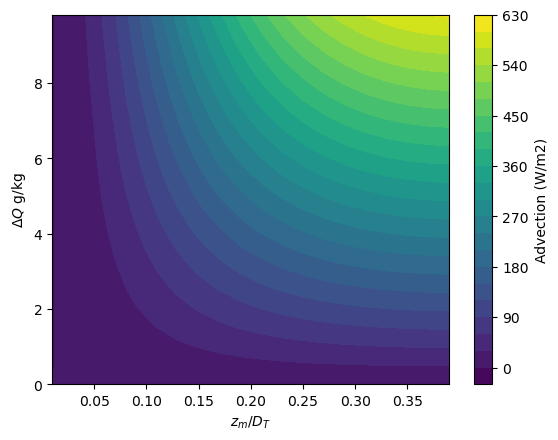

In [178]:
plt.contourf(measures/D_T, delta_Qs, advection.T, 20)
plt.colorbar(label ="Advection (W/m2)")
plt.xlabel("$z_m/D_T$")
plt.ylabel("$\Delta Q$ g/kg")

In [277]:
measure1 = 1
measure = 2.4
D_Ts = np.arange(20, 200, 30)
le_factors = np.arange(0, 1, 0.05)

advection = np.ones([len(D_Ts), len(le_factors)])
advection_ratio = np.ones([len(D_Ts), len(le_factors)])
delta_Qs = np.ones_like(le_factors)


for j,le_factor in enumerate(le_factors):
    
    p = Params(ustar_f = ustar_f, ustar_c = ustar_c, lm_option = 'kz', 
               avail_ratio = 1, Hmax = 20, Lx= 350,
               le_factor = le_factor, dz = 0.1, dx = 0.5)

    out = p.solve_surface_radiation_inplace(fix="alpha_c")
    out = p.update_surface_BCs_from_zom()

    T_uniform, FluxT_uniform = uniform_T(p)
    Q_uniform, FluxQ_uniform = uniform_Q(p)

    T_up, FluxT_upwind = get_upwind_fluxT(p)
    Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

    H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
    LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
    FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

    H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
    LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
    FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2
    delta_Qs[j] = Q_uniform[10, 0] - Q_up[0] 

    for i, D_T in enumerate(D_Ts):

        ind_x = np.where(p.x > D_T)[0][0]
        ind_z = np.where(p.z > measure)[0][0]
        ind_z1 = np.where(p.z > measure1)[0][0]        
        advection[i, j] = LE_uniform_Wm2[ind_x, 0] - LE_uniform_Wm2[ind_x, ind_z] 
        advection_ratio[i, j] = LE_uniform_Wm2[ind_x, ind_z] / LE_uniform_Wm2[ind_x, ind_z1] 

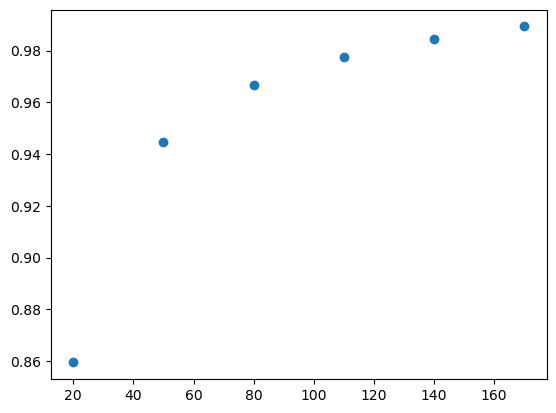

In [293]:
plt.plot(D_Ts, advection_ratio[:, 1], 'o')

Text(0, 0.5, '$\\Delta Q$ g/kg')

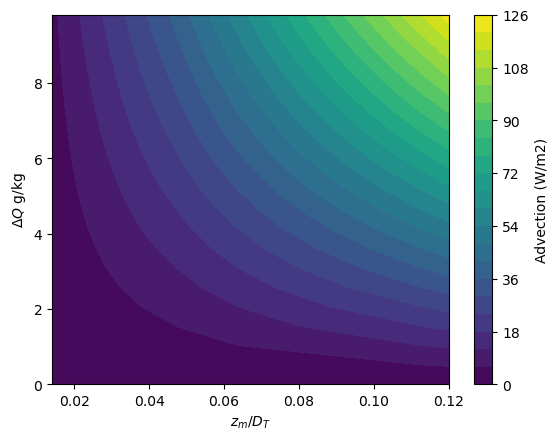

In [180]:
plt.contourf(measure/D_Ts, delta_Qs, advection.T, 20)
plt.colorbar(label ="Advection (W/m2)")
plt.xlabel("$z_m/D_T$")
plt.ylabel("$\Delta Q$ g/kg")

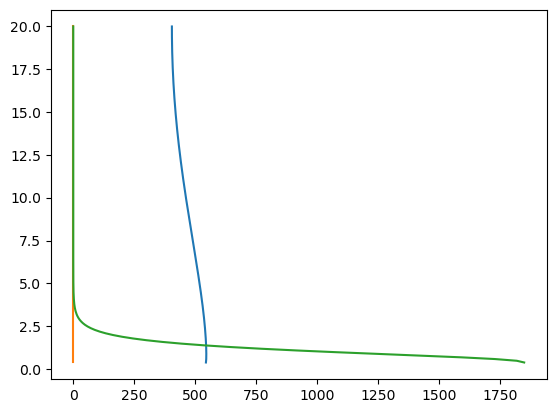

In [181]:
plt.plot(LE_uniform_Wm2[ind_x], p.z)
plt.plot(LE_upwind_Wm2, p.z)
plt.plot(LE_uniform_Wm2[1], p.z)
